In [1]:
from sionnart import SionnaRT
from mobility import SionnaMobility

/home/aung/anaconda3/envs/6G/lib/python3.12/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (8.0) - (12.0)
    
  queued_call()
pybullet build time: Jan  6 2026 23:44:17


In [2]:
IS_WAYPOINT = True

In [3]:
radio_settings = {
    "scene": "/home/aung/code/new_docte6g/assets/scenes/urban_micro/street_canyon.xml",
    # "scene": "/home/aung/code/new_docte6g/assets/scenes/free_space/free_space.xml",
    "carrier_frequency": 3.5e9, # 3.5 GHz
    "subcarrier_spacing": 30000, #30 kHz
    "num_subcarriers": 3276, # 100 MHz
    "tx_num_rows": 8,
    "tx_num_cols": 8,
    "rx_num_rows": 2,
    "rx_num_cols": 2,
    "pattern": "tr38901",
    "polarization": "VH",
    "tx_locations": [[0.0, 0.0, 10.0]],
    "tx_names": ["gNB"],
    "tx_ids": [0],
    "tx_power": 46.0,
    "rx_locations": [[50.0, 50.0, 1.5], [0.0, 50.0, 1.5], [-50.0, 50.0, 1.5]],
    "rx_names": ["ue_1", "ue_2", "ue_3"],
    "rx_speed": [5.0, 5.0, 5.0],
    "rx_ids": [1, 2, 3],
    "rx_mesh": "/home/aung/code/new_docte6g/assets/objects/iw_hub/iw_hub.ply", 
    "rx_update_interval": 0.5,
    "virtual_position_min_steps": 40,
    "virtual_position_num_angles": 72,
    "propagation_record_mode": "current_only"#"future_records",
}

mobility_settings = {
    "scene": "/home/aung/code/new_docte6g/assets/scenes/urban_micro/street_canyon.obj",
    "tx_locations": [[0.0, 0.0, 10.0]],
    "tx_names": ["gNB"],
    "tx_ids": [0],
    "tx_modes": ["CONSTANT_POSITION"],
    "tx_power": 46.0,
    "rx_locations": [[50.0, 50.0, 0.0], [0.0, 50.0, 0.0], [-50.0, 50.0, 0.0]],
    "rx_names": ["ue_1", "ue_2", "ue_3"],
    "rx_ids": [1, 2, 3],
    "rx_modes":["WAYPOINT","WAYPOINT", "WAYPOINT"] if IS_WAYPOINT else ["RANDOM_WALK","RANDOM_WALK", "RANDOM_WALK"],
    "rx_speed": [5.0, 5.0, 5.0],
    "rx_mesh": "/home/aung/code/new_docte6g/assets/objects/iw_hub/iw_hub.obj", 
}


In [4]:
sionnart = SionnaRT()
sionnart.initialize(radio_settings)

In [5]:
mobility = SionnaMobility()
mobility.initialize(mobility_settings)

In [6]:
# Cache management is handled internally by SionnaRT.perform_calculation()


In [7]:
import random


def generate_random_direction(min_x, max_x, min_y, max_y, z):
    x = random.uniform(min_x, max_x)
    y = random.uniform(min_y, max_y)
    return [x, y, z]


ues = ["ue_1", "ue_2", "ue_3"]
rx_height = 1.5
trajectories = {name: [] for name in ues}  # {ue: [[x,y,z], ...]}
rx_update_interval = float(radio_settings.get("rx_update_interval", 1.0))
simulation_duration = 500.0
num_steps = int(simulation_duration / rx_update_interval)
non_waypoint_replan_interval = 5.0
next_replan_times = {name: 0.0 for name in ues}

if IS_WAYPOINT:
    for i in range(len(ues)):
        dest_pos = generate_random_direction(-100, 100, -100, 100, 0.0)
        mobility.set_destination(ues[i], dest_pos)

all_records = []

for step in range(num_steps):
    timestamp = step * rx_update_interval
    for ue_name in ues:
        if not IS_WAYPOINT and timestamp + 1e-9 >= next_replan_times[ue_name]:
            dest_pos = generate_random_direction(-100, 100, -100, 100, 0.0)
            mobility.set_destination(ue_name, dest_pos)
            next_replan_times[ue_name] = timestamp + non_waypoint_replan_interval
        pos = mobility.update_position(ue_name, timestamp)
        if pos is not None:
            sionnart.update_position(ue_name, [pos[0], pos[1], rx_height])
            trajectories[ue_name].append(pos)

    records = sionnart.perform_calculation(timestamp)
    all_records.extend(records)

print(f"Total propagation records: {len(all_records)}")
print(f"Propagation calls: {sionnart.propagation_calculation_calls}")
print(f"Total receiver-calls: {sionnart.propagation_calculation_receiver_count}")


Total propagation records: 3000
Propagation calls: 1000
Total receiver-calls: 3000


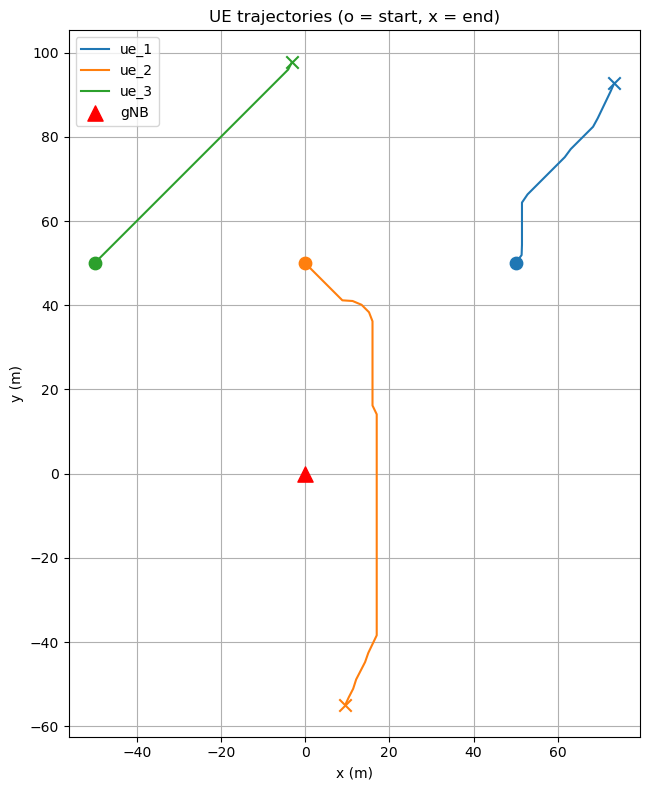

In [8]:
import matplotlib.pyplot as plt
import numpy as np

colors = {"ue_1": "tab:blue", "ue_2": "tab:orange", "ue_3": "tab:green"}

fig, ax = plt.subplots(figsize=(8, 8))
for name, pts in trajectories.items():
    if not pts:
        continue
    pts = np.array(pts)
    ax.plot(pts[:, 0], pts[:, 1], color=colors[name], label=name)
    ax.scatter(pts[0, 0],  pts[0, 1],  color=colors[name], marker="o", s=80, zorder=5)  # start
    ax.scatter(pts[-1, 0], pts[-1, 1], color=colors[name], marker="x", s=80, zorder=5)  # end

# gNB position
gnb = radio_settings["tx_locations"][0]
ax.scatter(gnb[0], gnb[1], color="red", marker="^", s=120, zorder=6, label="gNB")

ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("UE trajectories (o = start, x = end)")
ax.legend()
ax.grid(True)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()
